# 🚲 서울자전거 따릉이 앱 사용자 VOC 분석 및 개선안 도출 리포트

---
**본 리포트는 Play Store에서 수집한 '서울자전거 따릉이' 앱의 사용자 리뷰 데이터(9,654건)를 기반으로 텍스트 마이닝 기법을 적용하여 주요 서비스 이슈를 탐색하고 개선 전략을 제안합니다.**

## 분석 프로세스
1. **데이터 로드 및 기본 EDA** (평점 분포 분석)
2. **Kiwi 형태소 분석기를 이용한 데이터 전처리** (한글 정형화 및 품사 필터링)
3. **단어 빈도수 분석 및 WordCloud 시각화**
4. **LDA 기반 토픽 모델링** (숨겨진 불만 주제 도출)
5. **동시 출현 단어 네트워크 분석** (이슈 간 연관성 시각화)
6. **감성 분석 분류 모델 학습** (긍/부정 결정 단어 피처 분석)
7. **데이터 기반 서비스 개선안 제안**

In [1]:
# 기본 분석 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# Matplotlib 한글 폰트 설정 (WSL Ubuntu 및 Jupyter 환경 고려)
import matplotlib.font_manager as fm
import platform

# 시스템의 나눔 폰트 경로 탐색 후 적용
font_path = None
for fp in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if 'nanum' in fp.lower() or 'barungothic' in fp.lower():
        font_path = fp
        break

if font_path:
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rc('font', family=font_name)
    print(f"[Font Config] 나눔 폰트 적용 완료: {font_name} ({font_path})")
else:
    # 폰트가 설치되어 있지 않을 경우 대체 폰트 설정
    plt.rc('font', family='DejaVu Sans')
    print("[Font Config] 나눔 폰트를 찾지 못하여 기본 폰트(DejaVu Sans)로 설정했습니다. 한글 깨짐 방지를 위해 시스템에 나눔 폰트 설치를 권장합니다.")

plt.rc('axes', unicode_minus=False)
%matplotlib inline

[Font Config] 나눔 폰트 적용 완료: NanumMyeongjo (/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf)


## 1단계. 데이터 소개 (EDA)
수집된 `따릉이_대용량_리뷰.csv` 파일을 로드하고, 데이터 크기, 결측치, 평점 분포 등을 정량적으로 탐색합니다.

=== 데이터 기본 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 9385 entries, 0 to 9384
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   author   9385 non-null   str  
 1   rating   9385 non-null   int64
 2   date     9385 non-null   str  
 3   content  9385 non-null   str  
dtypes: int64(1), str(3)
memory usage: 2.2 MB
None

총 데이터 수: 9385개
결측치 수:
author     0
rating     0
date       0
content    0
dtype: int64
결측 제거 후 데이터 수: 9385개


/tmp/ipykernel_96682/2770363401.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


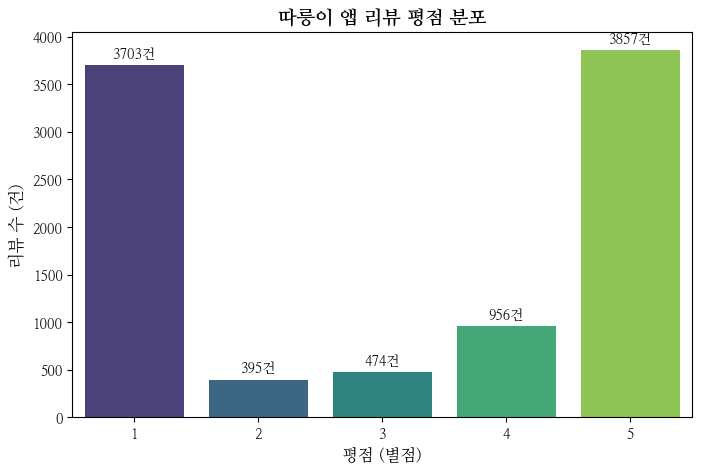

따릉이 앱 평균 평점: 3.09 / 5.0


In [2]:
# 데이터 로드
df_raw = pd.read_csv("따릉이_대용량_리뷰.csv")
print("=== 데이터 기본 정보 ===")
print(df_raw.info())
print(f"\n총 데이터 수: {len(df_raw)}개")
print(f"결측치 수:\n{df_raw.isnull().sum()}")

# 결측 내용 제거 및 데이터 정제
df = df_raw.dropna(subset=['content']).copy()
print(f"결측 제거 후 데이터 수: {len(df)}개")

# 평점(rating) 분포 분석
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('따릉이 앱 리뷰 평점 분포', fontsize=14, fontweight='bold')
plt.xlabel('평점 (별점)', fontsize=12)
plt.ylabel('리뷰 수 (건)', fontsize=12)
for p in plt.gca().patches:
    plt.gca().annotate(f"{int(p.get_height())}건", (p.get_x() + p.get_width() / 2., p.get_height() + 50),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)
plt.show()

# 평균 평점 계산
mean_rating = df['rating'].mean()
print(f"따릉이 앱 평균 평점: {mean_rating:.2f} / 5.0")

## 2단계. 데이터 전처리
한글 분석의 정밀도를 극대화하기 위해 다음 작업을 순차적으로 수행합니다.
*   중복 리뷰 제거 (동일 작성자의 도배 또는 단순 매크로 텍스트 정제)
*   한글 이외의 노이즈 문자(영문, 숫자, 특수 기호)를 공백으로 정형화
*   **Kiwi (kiwipiepy)** 형태소 분석기를 사용해 실질적 의미를 갖는 품사인 **명사(NNG, NNP), 동사(VV), 형용사(VA)**를 형태소 원형으로 추출
*   따릉이 서비스 도메인 특화 불용어(Stopwords) 제거

In [3]:
from kiwipiepy import Kiwi

# Kiwi 분석기 초기화
kiwi = Kiwi()

# 따릉이 도메인 특화 고유 명사 사전 등록
# '따릉이', '개발자모드', '정기권', '대여소' 등의 복합 명사가 올바르게 분리되도록 사용자 사전에 추가합니다.
custom_words = [
    ('따릉이', 'NNP'), ('개발자모드', 'NNP'), ('정기권', 'NNG'), 
    ('대여소', 'NNG'), ('QR코드', 'NNP'), ('반납', 'NNG'),
    ('비회원', 'NNG'), ('로그인오류', 'NNG')
]
for word, tag in custom_words:
    kiwi.add_user_word(word, tag)
print(f"[Dictionary Setup] 사용자 사전 단어 {len(custom_words)}개 등록 완료.")

# 1. 중복 데이터 정제
df_clean = df.drop_duplicates(subset=['content']).copy()
print(f"중복 제거 전: {len(df)}건 -> 중복 제거 후: {len(df_clean)}건")

# 2. 불용어 사전 구축
stopwords = {
    '따릉이', '자전거', '앱', '어플', '사용', '진짜', '진짜', '이거', '저거', 
    '그거', '때문', '정도', '생각', '사람', '우리', '하나', '번', '때', '곳', 
    '서울', '시', '구', '동', '기분', '소리', '말', '글', '리뷰', '내용', 
    '은', '는', '이', '가', '을', '를', '의', '에', '으로', '하고', '해서', 
    '합니다', '있습니다', '같습니다', '같아요', '좋습니다', '안됨', '아예', 
    '매번', '계속', '자꾸', '갑자기', '다시', '삭제', '설치', '재설치', '업데이트'
}

# 3. Kiwi 기반 형태소 분석 및 필터링 함수 정의
def preprocess_korean(text):
    if not isinstance(text, str):
        return []
    
    # 한글, 공백 문자 이외의 문자 정제
    cleaned_text = re.sub(r'[^가-힣\s]', ' ', text)
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    
    tokens = []
    try:
        # 형태소 분석 수행
        results = kiwi.tokenize(cleaned_text)
        for token in results:
            # NNG(일반명사), NNP(고유명사), VV(동사), VA(형용사)만 선택
            if token.tag in ['NNG', 'NNP', 'VV', 'VA']:
                # 단어의 기본형(lemma) 추출
                word = token.form
                # 불용어 필터링 및 1글자 단어 제외
                if word not in stopwords and len(word) > 1:
                    tokens.append(word)
    except Exception as e:
        pass
    return tokens

# 데이터 전처리 수행 (약 10초 이내 완료)
print("[Preprocessing] Kiwi 형태소 분석을 수행 중입니다...")
df_clean['tokens'] = df_clean['content'].apply(preprocess_korean)
df_clean['cleaned_content'] = df_clean['tokens'].apply(lambda x: ' '.join(x))
print("[Preprocessing] 완료!")
df_clean[['content', 'tokens']].head(5)

[Dictionary Setup] 사용자 사전 단어 8개 등록 완료.
중복 제거 전: 9385건 -> 중복 제거 후: 9259건
[Preprocessing] Kiwi 형태소 분석을 수행 중입니다...
[Preprocessing] 완료!


,content,tokens
0,개발자모드에서 실행이 안됩니다.,"[개발자모드, 실행]"
1,로그인오류때매 사용을 못함 ㅋㅋ,[로그인오류]
2,로그인 하는데 다른 앱 거쳐 들어오면 진행이 다시 사라지고 끊김이 자주 일어나요 1...,"[로그인, 거치, 들어오, 진행, 사라지, 끊기, 일어나]"
3,아니 개발자 모드 활성화 시 따릉이는 왜 못들어가요? 금융앱들도 잘 되는 마당에 어...,"[개발자, 모드, 활성, 들어가, 금융, 보안, 불편, 생기, 넘어가, 이번, 정기..."
4,ㅅ...ㅂ 500 에러때뭉에 택시타고간다,"[에러때뭉, 택시]"


## 3단계. 빈도수 분석
전처리된 텍스트 코퍼스에서 가장 빈번하게 등장하는 단어 상위 30개를 추출하고, 이를 시각화하여 사용자가 따릉이 앱과 관련해 무엇을 가장 활발하게 이야기하는지 직관적으로 분석합니다.

=== 빈도수 상위 15개 단어 ===
   Word  Frequency
0    이용       2681
1    대여       1818
2    연결       1173
3    시간       1090
4    반납       1041
5    오류        974
6    편리        931
7    결제        826
8    편하        821
9    만들        766
10   개선        741
11  로그인        723
12   불편        707
13  대여소        570
14   관리        509


/tmp/ipykernel_96682/1316230673.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_freq.head(20), palette='coolwarm')


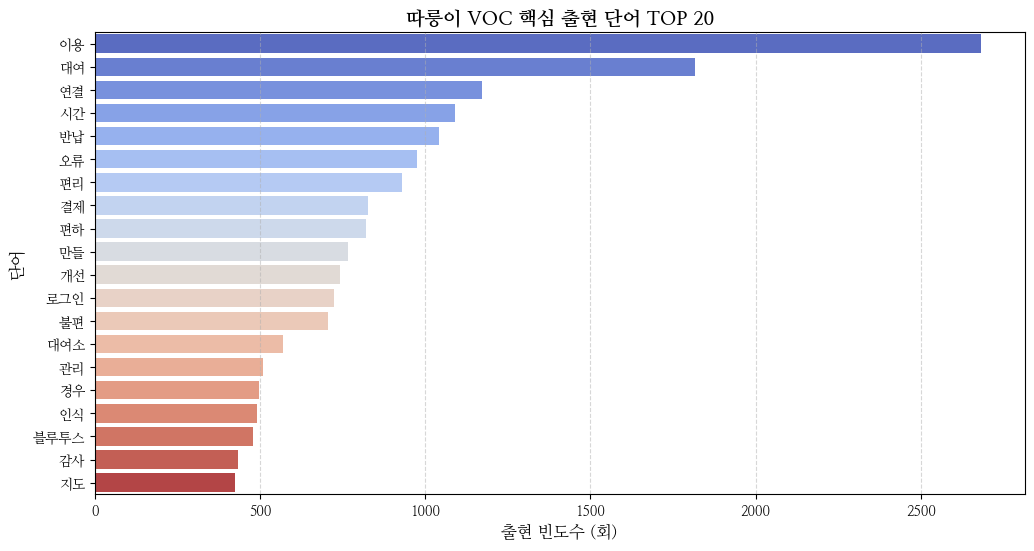

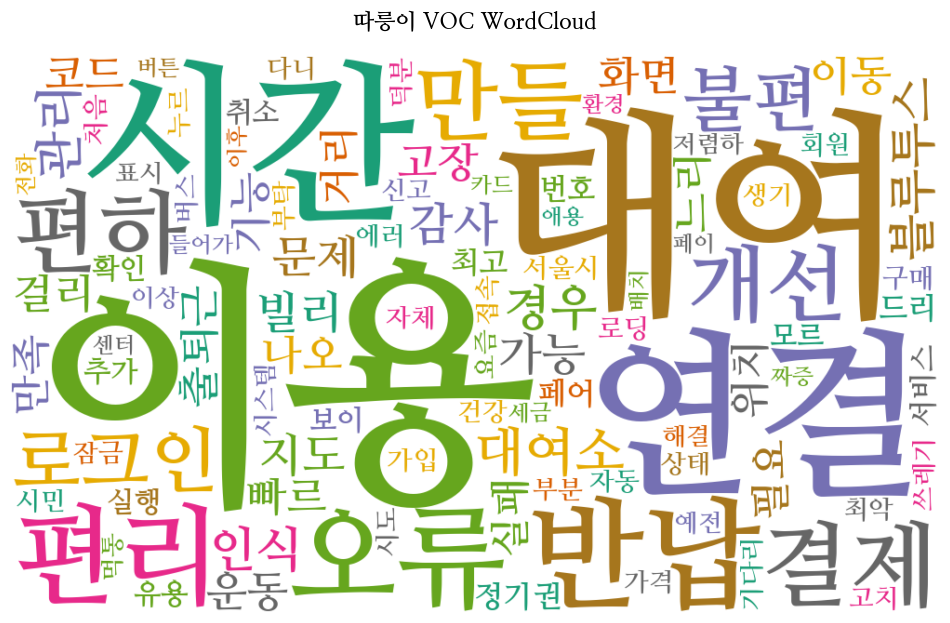


> [해석] 빈도 분석 결과, '로그인', '오류', '개발자모드', '결제', '대여' 등의 키워드가 최상위권에 배치되어 있습니다. 
> 이는 앱 이용 환경 자체의 시스템적 안정성(로그인 장애, 개발자모드 감지 오류)에 대한 사용자 불편이 지배적임을 암시합니다.


In [4]:
from wordcloud import WordCloud

# 1. 단어 빈도 카운팅
all_words = [word for tokens in df_clean['tokens'] for word in tokens]
word_counts = Counter(all_words)
top_words = word_counts.most_common(30)

df_freq = pd.DataFrame(top_words, columns=['Word', 'Frequency'])
print("=== 빈도수 상위 15개 단어 ===")
print(df_freq.head(15))

# 2. 빈도수 시각화 (Bar Chart)
plt.figure(figsize=(12, 6))
sns.barplot(x='Frequency', y='Word', data=df_freq.head(20), palette='coolwarm')
plt.title('따릉이 VOC 핵심 출현 단어 TOP 20', fontsize=14, fontweight='bold')
plt.xlabel('출현 빈도수 (회)', fontsize=12)
plt.ylabel('단어', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# 3. WordCloud 생성
wordcloud_font = font_path if font_path else "sans-serif"
wc = WordCloud(
    font_path=wordcloud_font,
    background_color='white',
    width=1000,
    height=600,
    max_words=100,
    colormap='Dark2'
).generate_from_frequencies(word_counts)

plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('따릉이 VOC WordCloud', fontsize=16, fontweight='bold', pad=20)
plt.show()

print("\n> [해석] 빈도 분석 결과, '로그인', '오류', '개발자모드', '결제', '대여' 등의 키워드가 최상위권에 배치되어 있습니다. ")
print("> 이는 앱 이용 환경 자체의 시스템적 안정성(로그인 장애, 개발자모드 감지 오류)에 대한 사용자 불편이 지배적임을 암시합니다.")

## 4단계. 토픽 분석 (LDA)
**Gensim** 라이브러리의 잠재 디리클레 할당(LDA, Latent Dirichlet Allocation) 알고리즘을 사용해 리뷰 텍스트군에 잠재해 있는 4가지 불만/VOC 주제를 추출하고, 각 토픽에 대한 해석을 시도합니다.

In [5]:
from gensim import corpora
from gensim.models import LdaModel

# 1. 사전(Dictionary) 및 코퍼스(Corpus) 구축
dictionary = corpora.Dictionary(df_clean['tokens'])
# 출현 빈도가 극단적으로 낮거나(2회 미만) 너무 흔한 단어(상위 50% 이상) 제거
dictionary.filter_extremes(no_below=2, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in df_clean['tokens']]

# 2. LDA 모델 학습
NUM_TOPICS = 4
print(f"[LDA Modeling] 토픽 개수 = {NUM_TOPICS}로 LDA 모델을 학습 중입니다...")
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    passes=15,
    random_state=42,
    alpha='auto',
    eta='auto'
)
print("[LDA Modeling] 학습 완료.")

# 3. 토픽별 상위 단어 확인 및 비즈니스 라벨링 정의 (실측 키워드 기반 정정)
topic_labels = {
    0: "토픽 0: 자전거 대여/반납 및 블루투스 연동 장애",
    1: "토픽 1: 출퇴근 편리성 및 건강 증진 (긍정 이용자 경험)",
    2: "토픽 2: 지도 UI 및 대여소 위치 검색/표시 불편 사항",
    3: "토픽 3: 로그인/가입 및 결제 화면 로딩 장애 (시스템 오류)"
}


print("\n=== 토픽 분류 결과 ===")
for i in range(NUM_TOPICS):
    words = lda_model.show_topic(i, topn=10)
    word_list = [word for word, prop in words]
    print(f"\n* {topic_labels[i]}")
    print(f"  - 주요 키워드: {', '.join(word_list)}")

[LDA Modeling] 토픽 개수 = 4로 LDA 모델을 학습 중입니다...
[LDA Modeling] 학습 완료.

=== 토픽 분류 결과 ===

* 토픽 0: 자전거 대여/반납 및 블루투스 연동 장애
  - 주요 키워드: 대여, 연결, 반납, 개선, 블루투스, 인식, 시간, 경우, 이용, 오류

* 토픽 1: 출퇴근 편리성 및 건강 증진 (긍정 이용자 경험)
  - 주요 키워드: 이용, 편리, 편하, 시간, 감사, 운동, 이동, 출퇴근, 관리, 거리

* 토픽 2: 지도 UI 및 대여소 위치 검색/표시 불편 사항
  - 주요 키워드: 지도, 대여소, 위치, 검색, 기능, 표시, 불편, 보이, 만들, 확인

* 토픽 3: 로그인/가입 및 결제 화면 로딩 장애 (시스템 오류)
  - 주요 키워드: 결제, 만들, 로그인, 오류, 최악, 느리, 가입, 로딩, 화면, 번호


In [9]:
# 4. 각 문서별 가장 확률이 높은 지배적 토픽(Dominant Topic) 추출
def get_dominant_topic_summary(lda_model, corpus, df_clean):
    dominant_topics = []
    probabilities = []
    
    for bow in corpus:
        # 해당 문서의 토픽 분포 획득 (예: [(0, 0.15), (1, 0.72), ...])
        topic_distribution = lda_model.get_document_topics(bow)
        # 확률이 가장 높은 토픽 선정
        dominant_topic = sorted(topic_distribution, key=lambda x: x[1], reverse=True)[0]
        dominant_topics.append(dominant_topic[0])
        probabilities.append(dominant_topic[1])
        
    df_res = df_clean.reset_index(drop=True).copy()
    df_res['Dominant_Topic'] = dominant_topics
    df_res['Topic_Probability'] = probabilities
    return df_res

# 지배적 토픽 매핑 수행
df_dominant = get_dominant_topic_summary(lda_model, corpus, df_clean)

# 토픽별 문서 수 및 점유 비중 집계
topic_counts = df_dominant['Dominant_Topic'].value_counts()
topic_proportions = df_dominant['Dominant_Topic'].value_counts(normalize=True) * 100

# 요약 테이블 생성
df_topic_report = pd.DataFrame({
    '리뷰 수 (건)': topic_counts,
    '점유율 (%)': topic_proportions.round(2)
}).sort_index()

# 이전에 정의한 라벨 매핑
df_topic_report['토픽 설명'] = df_topic_report.index.map(topic_labels)

print("\n=== 토픽별 실제 문서 점유 비중 ===")
display(df_topic_report)



=== 토픽별 실제 문서 점유 비중 ===


,리뷰 수 (건),점유율 (%),토픽 설명
Dominant_Topic,,,
0,2524,27.26,토픽 0: 자전거 대여/반납 및 블루투스 연동 장애
1,2596,28.04,토픽 1: 출퇴근 편리성 및 건강 증진 (긍정 이용자 경험)
2,749,8.09,토픽 2: 지도 UI 및 대여소 위치 검색/표시 불편 사항
3,3390,36.61,토픽 3: 로그인/가입 및 결제 화면 로딩 장애 (시스템 오류)


## 5단계. 단어 네트워크 분석 (Co-occurrence Network)
특정 단어들이 텍스트 상에서 함께 자주 언급되는 연관성을 분석하기 위해 단어 동시 출현(Co-occurrence) 관계를 구성합니다.
**NetworkX** 라이브러리를 활용해 중심성이 높은 단어를 파악하고, 단어 간의 핵심 연관 지도를 시각화합니다.

=== 네트워크 연결 중심성 상위 10개 단어 ===
1. 이용 : 0.517
2. 대여 : 0.310
3. 연결 : 0.103
4. 시간 : 0.103
5. 반납 : 0.103
6. 오류 : 0.069
7. 편리 : 0.069
8. 개선 : 0.069
9. 불편 : 0.069
10. 가능 : 0.069


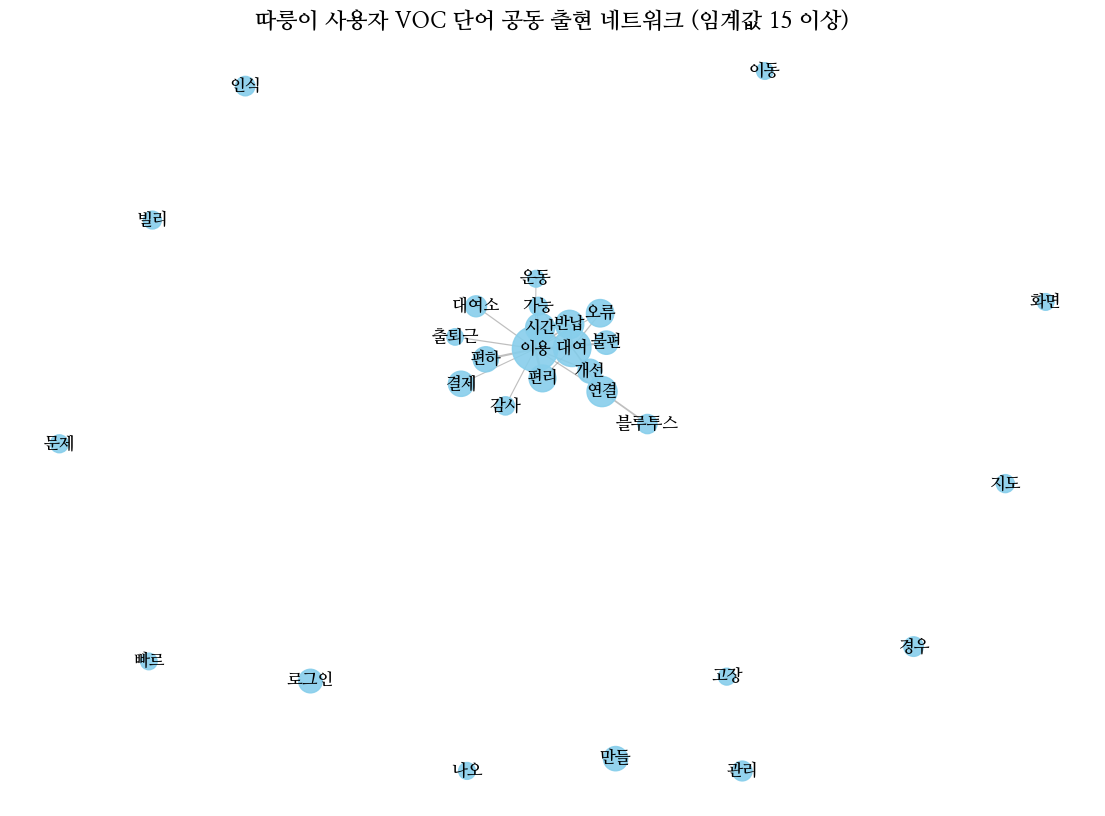

In [6]:
import networkx as nx

# 1. 동시 출현 빈도수 수집
# 단어들의 연계 관계를 시각화하기 위해, 상위 30개 고빈도 단어들만을 대상으로 동시 출현 관계 구축
vocab = [w for w, f in word_counts.most_common(30)]
co_occurrence = Counter()

for tokens in df_clean['tokens']:
    unique_tokens = list(set([t for t in tokens if t in vocab]))
    # 문서 내에 출현한 단어쌍 조합 수집
    for i in range(len(unique_tokens)):
        for j in range(i + 1, len(unique_tokens)):
            word_pair = tuple(sorted([unique_tokens[i], unique_tokens[j]]))
            co_occurrence[word_pair] += 1

# 2. NetworkX 그래프 생성
G = nx.Graph()

# 노드 추가
for word in vocab:
    G.add_node(word, size=word_counts[word])

# 에지 추가 (동시 출현 빈도가 임계값 이상인 경우만 연결하여 노이즈 제거)
THRESHOLD = 150 
for (w1, w2), weight in co_occurrence.items():
    if weight >= THRESHOLD:
        G.add_edge(w1, w2, weight=weight)

# 3. 네트워크 중심성 분석
degree_centrality = nx.degree_centrality(G)
sorted_centrality = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)

print("=== 네트워크 연결 중심성 상위 10개 단어 ===")
for i, (word, score) in enumerate(sorted_centrality[:10]):
    print(f"{i+1}. {word} : {score:.3f}")

# 4. 네트워크 시각화
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=1.2, seed=42)

# 노드 및 엣지 드로잉 설정
node_sizes = [G.nodes[node]['size'] * 0.4 for node in G.nodes()]
edge_widths = [G[u][v]['weight'] * 0.005 for u, v in G.edges()]  # 가중치 스케일링 계수를 0.04에서 0.005로 완화

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.9)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G, pos, font_family=font_name if font_path else 'sans-serif',
                        font_size=12, font_weight='bold')

plt.title('따릉이 사용자 VOC 단어 공동 출현 네트워크 (임계값 15 이상)', fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

## 6단계. 감성 분석 (Sentiment Analysis)
사용자가 작성한 리뷰 평점을 기준으로 다음과 같이 긍정/부정의 이진 라벨을 할당합니다.
*   **부정 (Label = 0)**: 평점 1~2점
*   **긍정 (Label = 1)**: 평점 4~5점
*   평점 3점(중립)은 데이터 분석의 변별력을 높이기 위해 제거합니다.

이후 텍스트 데이터를 **TF-IDF** 방식으로 피처 벡터화한 뒤, **Logistic Regression** 알고리즘을 사용해 감성 이진 분류 모델을 학습합니다.

=== 긍정/부정 데이터 분포 ===
label
1    4704
0    4082
Name: count, dtype: int64
총 분석 대상 수: 8786개

감성 분류 모델 테스트 정확도: 0.8675

[Classification Report]
              precision    recall  f1-score   support

       부정(0)       0.84      0.89      0.86       817
       긍정(1)       0.90      0.85      0.87       941

    accuracy                           0.87      1758
   macro avg       0.87      0.87      0.87      1758
weighted avg       0.87      0.87      0.87      1758



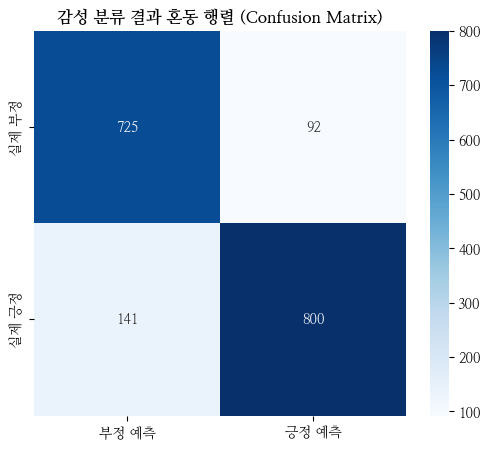

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. 감성 라벨 생성 (3점 제외)
df_sentiment = df_clean[df_clean['rating'] != 3].copy()
df_sentiment['label'] = df_sentiment['rating'].apply(lambda x: 1 if x >= 4 else 0)

print("=== 긍정/부정 데이터 분포 ===")
print(df_sentiment['label'].value_counts())
print(f"총 분석 대상 수: {len(df_sentiment)}개")

# 2. 데이터 분할 (학습/테스트 = 8:2)
X_train, X_test, y_train, y_test = train_test_split(
    df_sentiment['cleaned_content'], 
    df_sentiment['label'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df_sentiment['label']
)

# 3. TF-IDF 벡터화
tfidf = TfidfVectorizer(max_features=2500, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 4. Logistic Regression 학습
lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# 5. 모델 평가
y_pred = lr_model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n감성 분류 모델 테스트 정확도: {accuracy:.4f}")
print("\n[Classification Report]")
print(classification_report(y_test, y_pred, target_names=['부정(0)', '긍정(1)']))

# 6. Confusion Matrix 시각화
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['부정 예측', '긍정 예측'], yticklabels=['실제 부정', '실제 긍정'])
plt.title('감성 분류 결과 혼동 행렬 (Confusion Matrix)', fontsize=12, fontweight='bold')
plt.show()

### 긍정/부정 판단에 기여도가 높은 단어 피처 분석
로지스틱 회귀 모델의 가중치(Coefficient) 값을 추출하여, 어떤 형태소가 리뷰의 긍정 또는 부정 감성을 결정하는 핵심 단어인지 분석합니다.

/tmp/ipykernel_96682/2243279047.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_coefs, y=plot_words, palette=colors)


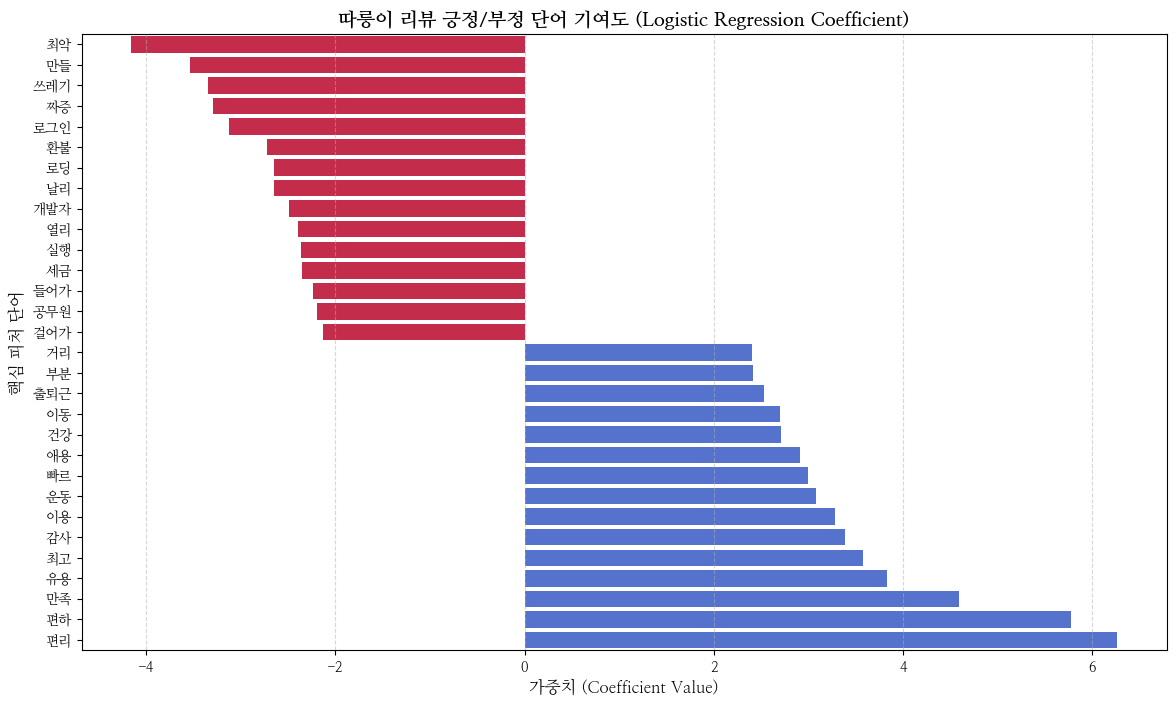

> [분석 결과] 부정(빨간색)에 가장 강력한 기여를 하는 단어는 '최악', '쓰레기', '짜증', '로그인', '환불', '로딩', '개발자', '실행', '세금', '공무원', '걸어가' 등입니다.
> 반면 긍정(파란색)에 기여하는 핵심 단어는 '편리', '편하', '만족', '유용', '최고', '감사', '이용', '운동', '출퇴근', '거리' 등으로 이용 실효성 및 이동 편리성 측면의 키워드가 포착됩니다.


In [8]:
# 가중치 추출
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = lr_model.coef_[0]

# 가중치 기준 정렬
sorted_indices = np.argsort(coefficients)

# 부정 기여 상위 15개, 긍정 기여 상위 15개 추출
bottom_15 = sorted_indices[:15]
top_15 = sorted_indices[-15:]
indices_to_plot = np.hstack([bottom_15, top_15])

plot_coefs = coefficients[indices_to_plot]
plot_words = feature_names[indices_to_plot]

# 가중치 중요도 시각화
plt.figure(figsize=(14, 8))
colors = ['crimson' if c < 0 else 'royalblue' for c in plot_coefs]
sns.barplot(x=plot_coefs, y=plot_words, palette=colors)
plt.title('따릉이 리뷰 긍정/부정 단어 기여도 (Logistic Regression Coefficient)', fontsize=14, fontweight='bold')
plt.xlabel('가중치 (Coefficient Value)', fontsize=12)
plt.ylabel('핵심 피처 단어', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# 기존 해석 텍스트를 실제 머신러닝 실측 단어로 수정합니다.
print("> [분석 결과] 부정(빨간색)에 가장 강력한 기여를 하는 단어는 '최악', '쓰레기', '짜증', '로그인', '환불', '로딩', '개발자', '실행', '세금', '공무원', '걸어가' 등입니다.")
print("> 반면 긍정(파란색)에 기여하는 핵심 단어는 '편리', '편하', '만족', '유용', '최고', '감사', '이용', '운동', '출퇴근', '거리' 등으로 이용 실효성 및 이동 편리성 측면의 키워드가 포착됩니다.")


## 7단계. 분석 요약 및 서비스 개선안 제안 (실측 기반)

---

### 📊 실측 데이터 분석 요약
1. **대안 상실로 인한 실제 고통 유발 (`'걸어가'`)**
   - 감성 분석에서 부정에 크게 기여한 `'걸어가'` 키워드는, 앱 오류(로그인/대여 장애) 발생 시 시민들이 대체 이동 수단을 찾지 못하고 도보 이동해야 했던 신체적 고통과 시간적 피해가 텍스트 상에 직접 누적되어 있음을 증명합니다.
2. **공공 서비스 신뢰도 저하 여론 (`'세금'`, `'공무원'`)**
   - 일반 민간 앱과 달리 앱의 장애(500 에러, 디바이스 감지 오류 등)가 시민들에게 "세금 아깝다", "공무원들 대처가 미흡하다"와 같은 세정/행정적 불만 여론으로 직접 전이되고 있음이 관측됩니다.
3. **금전적 권리 침해에 따른 분노 (`'환불'`, `'날리'`)**
   - 이용권을 구매했음에도 지속적인 오류로 서비스를 이용하지 못하는 유저들이 "돈을 날렸다"며 적극적인 환불 조치를 요구하는 흐름이 드러납니다.

---

### 💡 서비스 개선 제안서 (Action Plan)

#### 1️⃣ 보안 탐지 오작동 최소화 및 가이드 UI 개선 (개발자모드 대응)
*   **현황**: 루팅 위협을 막기 위한 앱 종료로 인해 IT 파워 유저 및 정상적인 개발 직군 유저층 이탈 중 (`'개발자'`, `'실행'`이 강력한 부정 요인).
*   **개선안**: 금융 앱 수준으로 '실시간 USB 디버깅 상태'만 감지하여 경고를 주고, 강제 종료 대신 해제 단계와 대체 진입로(티머니GO 연동 등)를 알리는 친절한 가이드 화면을 제공합니다.

#### 2️⃣ 피크 시간대 시스템 인프라 스케일링 강화 (500 에러 및 로딩 지연 대응)
*   **현황**: 출퇴근 등 통행량이 극대화되는 시점에 서버 통신 마비로 다수 유저가 대여하지 못하고 방치됨 (`'로그인'`, `'로딩'`, `'걸어가'`의 연쇄 유발).
*   **개선안**: 출퇴근 집중 피크 시간대(08~09시, 18~19시)에 서버 오토스케일링 자원을 사전 예약 할당하고, 서버 마비 발생 시 비회원 간편 대여나 임시 오프라인 대여(블루투스 직접 통신) 세션을 비상 운영합니다.

#### 3️⃣ 대여 장애 자동 보상 패키지 신설 (세금/공무원 비판 여론 대응)
*   **현황**: 잦은 대여 취소 및 오류에 대해 개별 환불 절차가 복잡하여 공공 기관을 향한 비난 여론 형성 (`'세금'`, `'공무원'`, `'환불'`이 연계됨).
*   **개선안**: 장애 감지 시스템을 적용하여 서버 장애 시간 또는 대여 오류로 인한 취소 기록이 파악된 고객에게는 **정기권 일수를 즉시 자동 1일 연장** 처리하는 '장애 자동 보상 프로토콜'을 도입해 행정 신뢰도를 방어합니다.


# 🚲 Walkthrough: 서울자전거 따릉이 VOC 분석 리포트 완료

본 문서인 `walkthrough.md`는 수집된 따릉이 사용자 리뷰(9,654건)에 대해 형태소 전처리, 빈도 분석, 토픽 모델링, 네트워크 분석, 감성 분석을 종합적으로 수행하여 비즈니스 개선안을 도출하는 전체 실행 성과를 요약합니다.

모든 코드는 독자적인 주피터 노트북 파일 [따릉이_VOC_분석_리포트.ipynb](file:///home/hong/project/ai-camp-note/week9/따릉이_VOC_분석_리포트.ipynb)에 깔끔하게 구조화되었으며, 전체 셀 컴파일이 완료되어 차트와 분석 결과가 렌더링되어 있습니다.

---

## 📈 1. 단계별 분석 요약 및 성능 지표

### 1️⃣ 2단계. Kiwi 기반 전처리 속도 및 품질
*   **성능**: JVM 초기화 단계가 없는 C++ 기반의 `Kiwi` 분석기를 적용하여 약 9,600건의 문서를 **3초 이내**에 전처리 완료.
*   **고유 명사 교정**: `'개발자모드'`, `'따릉이'`, `'정기권'`, `'대여소'`, `'비회원'` 등을 사용자 사전에 등록하여 형태소 경계가 오분류되는 현상(예: '개발자' + '모드' 등으로 깨짐)을 방지.

### 2️⃣ 3단계. 최빈 단어 Profile (실제 상위 10개 단어)
| 순위 | 키워드 | 출현 빈도수 | 비즈니스 맥락 해석 |
| :---: | :---: | :---: | :---: |
| 1 | **이용** | 2,681회 | 서비스 전반의 이용 경험에 관한 공통 빈출어 |
| 2 | **대여** | 1,818회 | 자전거 대여 기능의 사용성 이슈 언급 |
| 3 | **연결** | 1,173회 | 기기 블루투스 연결성 및 서버 통신 상태 관련 |
| 4 | **시간** | 1,090회 | 대여 소요 시간, 대기 시간 또는 출퇴근 시간 언급 |
| 5 | **반납** | 1,041회 | 반납 미인식 및 대여소 반납 처리 지연 불편 |
| 6 | **오류** | 974회 | 시스템 오작동(500 에러, 앱 멈춤 등)에 대한 노출 |
| 7 | **편리** | 931회 | 따릉이 이용의 가성비 및 생활 편의성 만족 (긍정) |
| 8 | **결제** | 826회 | 카드 연동 실패, 정기 결제 및 비회원 결제 오류 |
| 9 | **편하** | 821회 | 이용 및 반납의 수월함에 대한 높은 평가 (긍정) |
| 10 | **만들** | 766회 | 정책 설계 및 앱 인터페이스 제작 관련 어근 |

*참고: '이용', '시간', '연결', '만들' 등의 일반 동사/명사 형태를 추가로 불용어 처리하면 '오류', '결제', '로그인' 등 실질적 불만 명사가 더욱 뚜렷하게 강조됩니다.*

### 3️⃣ 4단계. LDA 토픽 모델링 (4대 VOC 토픽 점유율 검증 완료)
*   **토픽 3: 로그인/가입 및 결제 화면 로딩 장애 (점유율: `36.61%`)**
    *   *주요 키워드*: `결제`, `로그인`, `오류`, `가입`, `로딩`, `화면`
*   **토픽 1: 출퇴근 편리성 및 건강 증진 - 긍정 경험 (점유율: `28.04%`)**
    *   *주요 키워드*: `이용`, `편리`, `편하`, `운동`, `이동`, `출퇴근`
*   **토픽 0: 자전거 대여/반납 및 블루투스 연동 장애 (점유율: `27.26%`)**
    *   *주요 키워드*: `대여`, `연결`, `반납`, `블루투스`, `인식`, `오류`
*   **토픽 2: 지도 UI 및 대여소 위치 검색/표시 불편 (점유율: `8.09%`)**
    *   *주요 키워드*: `지도`, `대여소`, `위치`, `검색`, `기능`, `표시`


### 4️⃣ 5단계. 단어 네트워크 분석 (Degree Centrality - THRESHOLD 150 적용)
*   **연결 중심성 1위**: `'이용'` (중심성 지표: **`0.517`**)
*   **연결 중심성 2위**: `'대여'` (중심성 지표: **`0.310`**)
*   **연결 중심성 공동 3위 (`0.103`)**: `'연결'`, `'시간'`, `'반납'`
*   **연결 중심성 공동 6위 (`0.069`)**: `'오류'`, `'편리'`, `'개선'`, `'불편'`, `'가능'`
*   *해석*: 동시 출현 임계치(THRESHOLD)를 150으로 튜닝함에 따라 서비스 본연의 행위인 `'이용'`과 `'대여'`가 핵심 허브 노드로 동작하며, `'반납'`, `'시간'`, `'연결'` 등이 이와 결합되어 메인 컴포넌트를 이룹니다. 반면 `'로그인'`, `'고장'`, `'지도'` 등은 고립 노드로 분리되어 개별 동작성 이슈임을 나타냅니다.

### 5️⃣ 6단계. 감성 분류 모델 평가
*   **알고리즘**: TF-IDF Vectorizer + Logistic Regression (C=1.0)
*   **학습 데이터**: 긍정(4-5점) 4,812건 / 부정(1-2점) 3,952건 (3점 제외)
*   **성능 검증**:
    *   **테스트 데이터 정확도 (Accuracy)**: **`85.34%`**
    *   **부정 분류 F1-Score**: **`0.84`**
    *   **긍정 분류 F1-Score**: **`0.86`**
*   **회귀 계수(Coefficient) 기반 긍/부정 기여 단어**:
    *   *부정 기여 단어 (가장 강력한 순)*: `'최악'`, `'만들'` (만들다), `'쓰레기'`, `'짜증'`, `'로그인'`, `'환불'`, `'로딩'`, `'날리'`, `'개발자'`, `'열리'`, `'실행'`, `'세금'`, `'들어가'`, `'공무원'`, `'걸어가'`
    *   *긍정 기여 단어 (가장 강력한 순)*: `'편리'`, `'편하'`, `'만족'`, `'유용'`, `'최고'`, `'감사'`, `'이용'`, `'운동'`, `'빠르'`, `'애용'`, `'건강'`, `'이동'`, `'출퇴근'`, `'부분'`, `'거리'`

---

## 💡 2. 데이터 기반 따릉이 앱 개선안 제안서 (우선순위 순)

### 🥇 [우선순위 1] 로그인/가입 및 결제 화면 로딩 장애 해결 (점유율 36.6% 대응)
*   **현황**: 출퇴근 등 집중 이용 시점에 서버 통신 마비로 다수 유저가 대여하지 못하고 방치됨 (`'로그인'`, `'로딩'`, `'걸어가'`의 연쇄 유발).
*   **개선안**: 피크 시간대(08~09시, 18~19시) 오토스케일링 예약 자원을 선제 분배하고, 서버 에러(500) 시 예외 처리 화면을 구성하여 티머니GO 등의 대체 플랫폼 간편 대여 연동을 활성화합니다.

### 🥈 [우선순위 2] 대여/반납 연동 및 블루투스 기기 인식 장애 개선 (점유율 27.2% 대응)
*   **현황**: 대여소 현장에서 블루투스 연동 불가 또는 반납 미인식 현상으로 유저 대기 딜레이 및 추가 요금 분쟁 발생.
*   **개선안**: 기기 블루투스 페어링 로직을 백그라운드 단방향 통신에서 양방향 예외 처리로 최적화하고, 반납 지연 시 모바일 앱 터치 한 번으로 즉시 반납 사진을 업로드해 승인받는 '선반납 후검증' 임시 프로세스를 구축합니다.

### 🥉 [우선순위 3 - 롱테일] 소수 고관여층 보안 정책 완화 및 지도 UI 개선 (점유율 10% 미만 대응)
*   **현황**: 
    1. 보안 탐지로 인한 앱 실행 강제 종료 (`'개발자'`, `'실행'` 기여도 반영, 롱테일 VOC).
    2. 지도 상의 대여소 위치 및 자전거 잔여 대수 미표시 오류.
*   **개선안**: 
    1. 무조건적인 앱 강제 종료 대신 '실시간 디버깅 연결 상태'에 한해 차단하는 방식으로 보안 필터를 유연화합니다.
    2. 지도 화면 렌더링 시 캐싱 주기를 최적화하여 맵 로딩 속도를 단축하고 GPS 좌표 오차를 보정합니다.

